# **1. Setup**

In [5]:
from google.colab import drive

# Mount Google Drive ke Google Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Data Checking & Preparation**

In [6]:
import os

# Folder utama project di Google Drive
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Sarbagita"

# Tampilkan path yang digunakan
print("Project directory:")
print(PROJECT_DIR)

files = os.listdir(PROJECT_DIR)

print("Files found:")
for file in files:
    print("-", file)

Project directory:
/content/drive/MyDrive/Colab Notebooks/ILASPP/Sarbagita
Files found:
- Sarbagita_2023.tif
- Sarbagita_2020.tif


## *2.1 Load raster 2020 & 2023*

In [7]:

# Lokasi raster tahun 2020
raster_2020 = os.path.join(
    PROJECT_DIR,
    "Sarbagita_2020.tif"
)

# Lokasi raster tahun 2023
raster_2023 = os.path.join(
    PROJECT_DIR,
    "Sarbagita_2023.tif"
)

# Cek path
print("2020:", raster_2020)
print("2023:", raster_2023)

2020: /content/drive/MyDrive/Colab Notebooks/ILASPP/Sarbagita/Sarbagita_2020.tif
2023: /content/drive/MyDrive/Colab Notebooks/ILASPP/Sarbagita/Sarbagita_2023.tif


In [8]:
import rasterio

print("Rasterio version:", rasterio.__version__)

Rasterio version: 1.5.1


## *2.2 Cek metadata (CRS, resolusi, bounds)*

In [9]:
for path in [raster_2020, raster_2023]:

    # Membuka raster
    with rasterio.open(path) as src:

        print("=" * 60)
        print("FILE:", os.path.basename(path))

        # Sistem koordinat
        print("CRS:", src.crs)

        # Jumlah pixel
        print("Width:", src.width)
        print("Height:", src.height)

        # Jumlah band
        print("Band count:", src.count)

        # Resolusi pixel
        print("Resolution:", src.res)

        # Extent / bounding box
        print("Bounds:", src.bounds)

        # Data type setiap band
        print("Data type:", src.dtypes)

        # Nilai NoData
        print("NoData:", src.nodata)

        print()

FILE: Sarbagita_2020.tif
CRS: EPSG:4326
Width: 5075
Height: 6789
Band count: 3
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=114.91518609042154, bottom=-8.849303863861406, right=115.3710810971122, top=-8.239437617472664)
Data type: ('uint8', 'uint8', 'uint8')
NoData: None

FILE: Sarbagita_2023.tif
CRS: EPSG:4326
Width: 5075
Height: 6789
Band count: 3
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=114.91518609042154, bottom=-8.849303863861406, right=115.3710810971122, top=-8.239437617472664)
Data type: ('uint8', 'uint8', 'uint8')
NoData: None



## *2.3 Cek statistik band*

In [10]:
for path in [raster_2020, raster_2023]:

    with rasterio.open(path) as src:

        print("=" * 60)
        print("FILE:", os.path.basename(path))

        # Loop untuk setiap band
        for band_number in range(1, src.count + 1):

            # Membaca satu band
            band = src.read(band_number, masked=True)

            print(
                f"Band {band_number}: "
                f"min={band.min()}, "
                f"max={band.max()}, "
                f"mean={band.mean():.2f}, "
                f"std={band.std():.2f}"
            )

        print()

FILE: Sarbagita_2020.tif
Band 1: min=0, max=255, mean=30.88, std=38.85
Band 2: min=0, max=255, mean=37.54, std=40.77
Band 3: min=0, max=255, mean=27.00, std=31.99

FILE: Sarbagita_2023.tif
Band 1: min=0, max=255, mean=36.12, std=44.73
Band 2: min=0, max=255, mean=41.38, std=44.83
Band 3: min=0, max=255, mean=29.65, std=35.74



## *2.4 Visualisasi RGB*

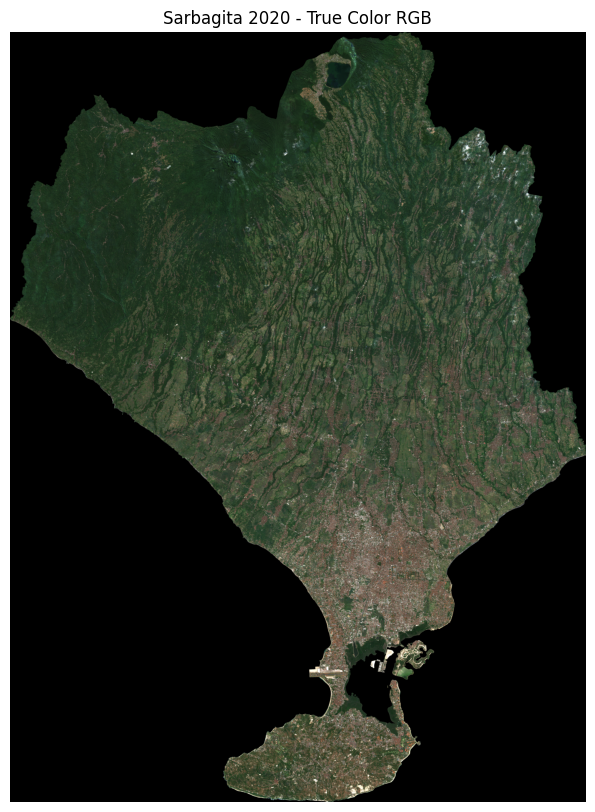

In [11]:
import matplotlib.pyplot as plt

# Membuka raster 2020
with rasterio.open(raster_2020) as src:

    # Membaca ketiga band RGB
    image_2020 = src.read([1, 2, 3])

    # Mengubah format:
    # dari (band, height, width)
    # menjadi (height, width, band)
    image_2020 = image_2020.transpose(1, 2, 0)

# Membuat plot
plt.figure(figsize=(12, 10))

plt.imshow(image_2020)

plt.title("Sarbagita 2020 - True Color RGB")
plt.axis("off")

plt.show()

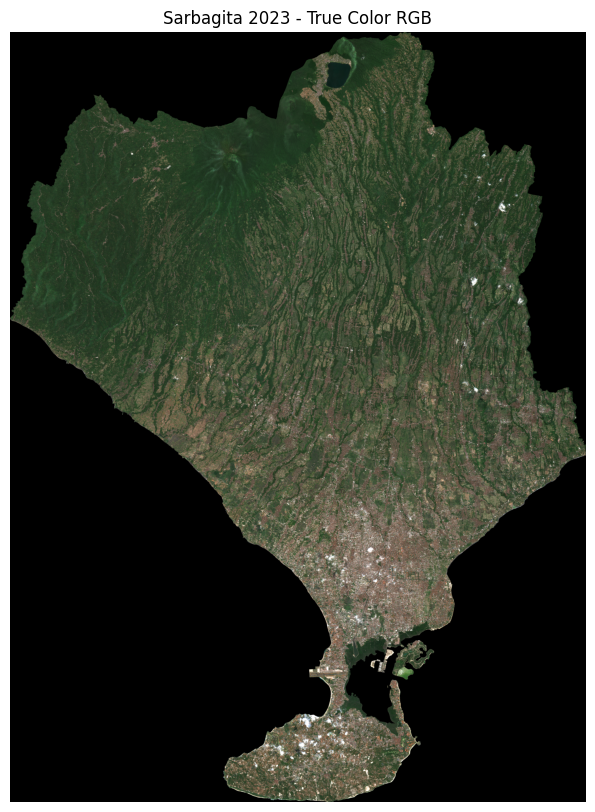

In [12]:
with rasterio.open(raster_2023) as src:

    # Membaca ketiga band RGB
    image_2023 = src.read([1, 2, 3])

    # Mengubah format array untuk matplotlib
    image_2023 = image_2023.transpose(1, 2, 0)

# Membuat plot
plt.figure(figsize=(12, 10))

plt.imshow(image_2023)

plt.title("Sarbagita 2023 - True Color RGB")
plt.axis("off")

plt.show()

In [13]:
with rasterio.open(raster_2020) as src_2020:
    profile_2020 = {
        "CRS": src_2020.crs,
        "Width": src_2020.width,
        "Height": src_2020.height,
        "Resolution": src_2020.res,
        "Bounds": src_2020.bounds
    }

with rasterio.open(raster_2023) as src_2023:
    profile_2023 = {
        "CRS": src_2023.crs,
        "Width": src_2023.width,
        "Height": src_2023.height,
        "Resolution": src_2023.res,
        "Bounds": src_2023.bounds
    }

print("2020:")
for key, value in profile_2020.items():
    print(f"{key}: {value}")

print("\n2023:")
for key, value in profile_2023.items():
    print(f"{key}: {value}")

2020:
CRS: EPSG:4326
Width: 5075
Height: 6789
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=114.91518609042154, bottom=-8.849303863861406, right=115.3710810971122, top=-8.239437617472664)

2023:
CRS: EPSG:4326
Width: 5075
Height: 6789
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=114.91518609042154, bottom=-8.849303863861406, right=115.3710810971122, top=-8.239437617472664)


# **3. Training Sample**

In [4]:
!pip install rasterio geopandas scikit-learn -q

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

## *Reload model dan Hasil Klasifikasi*
*run this with caution - tidak perlu training ulang (in case runtime error atau restart sendiri)*

In [14]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score
import joblib
from scipy import ndimage
from scipy.ndimage import median_filter

In [15]:
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Sarbagita"
raster_2020 = os.path.join(PROJECT_DIR, "Sarbagita_2020.tif")
raster_2023 = os.path.join(PROJECT_DIR, "Sarbagita_2023.tif")

# Load model yang sudah dilatih
model_path = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Model/rf_model.joblib"
rf_model = joblib.load(model_path)

# Load hasil klasifikasi yang sudah tersimpan sebagai .tif
output_dir = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Output"
with rasterio.open(os.path.join(output_dir, "LC_Sarbagita_2020.tif")) as src:
    classified_2020 = src.read(1)
with rasterio.open(os.path.join(output_dir, "LC_Sarbagita_2023.tif")) as src:
    classified_2023 = src.read(1)

print("Model dan hasil klasifikasi berhasil dimuat ulang.")
print("classified_2020 shape:", classified_2020.shape)
print("classified_2023 shape:", classified_2023.shape)

Model dan hasil klasifikasi berhasil dimuat ulang.
classified_2020 shape: (6789, 5075)
classified_2023 shape: (6789, 5075)


In [16]:
kelas_urut = [1, 2, 3, 4, 5]
nama_kelas = {1: "Built-up", 2: "Vegetation", 3: "Agriculture", 4: "Bare Land", 5: "Water Body"}

# Hitung ulang matriks transisi
valid_both = (classified_2020 != 0) & (classified_2023 != 0)
transisi = confusion_matrix(classified_2020[valid_both], classified_2023[valid_both], labels=kelas_urut)
prob_transisi = transisi / transisi.sum(axis=1, keepdims=True)

# Hitung ulang driving & restricting factor
is_builtup = (classified_2023 == 1)
distance_to_builtup = ndimage.distance_transform_edt(~is_builtup)
is_water = (classified_2023 == 5)

print("Variabel pendukung siap.")

Variabel pendukung siap.


In [17]:
def proyeksi_markov(base_classified, prob_transisi, distance_to_builtup, is_water, kelas_urut, seed=42):
    """Simulasi Markov Chain + driving factor (jarak built-up) + restricting factor (air dikunci)."""
    np.random.seed(seed)
    h, w = base_classified.shape
    hasil = base_classified.copy()

    max_dist = distance_to_builtup.max()
    skor_dekat_builtup = 1 - (distance_to_builtup / max_dist)

    for idx_asal, kelas_asal in enumerate(kelas_urut):
        mask_asal = (base_classified == kelas_asal)
        if mask_asal.sum() == 0:
            continue

        prob_baris = prob_transisi[idx_asal].copy()
        idx_builtup = kelas_urut.index(1)
        prob_baris_modif = np.tile(prob_baris, (mask_asal.sum(), 1))
        prob_baris_modif[:, idx_builtup] *= (1 + skor_dekat_builtup[mask_asal])
        prob_baris_modif = prob_baris_modif / prob_baris_modif.sum(axis=1, keepdims=True)

        kelas_baru = np.array([
            np.random.choice(kelas_urut, p=p) for p in prob_baris_modif
        ])
        hasil[mask_asal] = kelas_baru

    hasil[is_water] = 5
    return hasil

In [18]:
# Hindcast: simulasikan 2023 dari 2020
hindcast_2023 = proyeksi_markov(classified_2020, prob_transisi, distance_to_builtup, is_water, kelas_urut)

# Smoothing pakai median filter (cepat)
hindcast_2023_smooth = median_filter(hindcast_2023, size=3)

# Validasi setelah smoothing
valid_compare2 = (hindcast_2023_smooth != 0) & (classified_2023 != 0)
oa_smooth = accuracy_score(classified_2023[valid_compare2], hindcast_2023_smooth[valid_compare2])
kappa_smooth = cohen_kappa_score(classified_2023[valid_compare2], hindcast_2023_smooth[valid_compare2])

print(f"Hindcast setelah median filter (3x3):")
print(f"  Overall Accuracy: {oa_smooth:.4f} ({oa_smooth*100:.2f}%)")
print(f"  Cohen's Kappa: {kappa_smooth:.4f}")

Hindcast setelah median filter (3x3):
  Overall Accuracy: 0.6590 (65.90%)
  Cohen's Kappa: 0.4751


LANJUT KE CELL 9.2

## *3.1 Load shapefile training sample*

In [11]:
# Path training sample
training_path = "/content/drive/MyDrive/Colab Notebooks/ILASPP/TutupanLahan_2020/2020_WGS84.shp"

gdf = gpd.read_file(training_path)

# Convert kolom Class dari string ke integer (untuk rasterize)
gdf['Class'] = gdf['Class'].astype(int)

print("Jumlah polygon:", len(gdf))
print("Kolom:", gdf.columns.tolist())
print("CRS training sample:", gdf.crs)
print("Tipe data kolom Class:", gdf['Class'].dtype)
print(gdf.head())

Jumlah polygon: 47
Kolom: ['Id', 'Class', 'Descript', 'geometry']
CRS training sample: EPSG:4326
Tipe data kolom Class: int64
   Id  Class    Descript                                           geometry
0   0      2  Vegetation  POLYGON ((115.15279 -8.28385, 115.15281 -8.283...
1   0      5  Water Body  POLYGON ((115.17103 -8.28362, 115.17018 -8.283...
2   0      5  Water Body  POLYGON ((115.18903 -8.73443, 115.18872 -8.734...
3   0      5  Water Body  POLYGON ((115.18545 -8.74314, 115.18499 -8.743...
4   0      5  Water Body  POLYGON ((115.18691 -8.72347, 115.18681 -8.721...


In [12]:
# Cek CRS training sample
print("CRS training sample:", gdf.crs)

CRS training sample: EPSG:4326


## *3.2 Cek distribusi sample per kelas*

In [13]:
# Cek distribusi sample per kelas (pakai kolom 'Class' dan 'Descript')
print("Jumlah sample per kelas:")
print(gdf.groupby(['Class', 'Descript']).size())

print("\nTotal polygon:", len(gdf))

Jumlah sample per kelas:
Class  Descript   
1      Built-up       13
2      Vegetation      8
3      Agriculture    12
4      Bare Land       5
5      Water Body      9
dtype: int64

Total polygon: 47


# **4. Preprocessing**

## *4.1 Rasterisasi training sample*

In [14]:
# Buka raster 2020 untuk ambil referensi grid (transform, ukuran, CRS)
with rasterio.open(raster_2020) as src:
    img_transform = src.transform
    img_shape = (src.height, src.width)
    img_crs = src.crs

# Pastikan training sample pakai CRS yang sama persis dengan citra
assert gdf.crs == img_crs, f"CRS beda: sample={gdf.crs}, citra={img_crs}"

# Ubah polygon jadi raster label, tiap piksel diisi nilai 'Class'
# Piksel yang tidak ketutup polygon manapun diisi 0 (nanti dianggap 'bukan sample')
shapes = [(geom, value) for geom, value in zip(gdf.geometry, gdf['Class'])]

training_raster = rasterize(
    shapes=shapes,
    out_shape=img_shape,
    transform=img_transform,
    fill=0,
    dtype='uint8'
)

print("Ukuran training raster:", training_raster.shape)
print("Jumlah piksel per kelas:")
unique, counts = np.unique(training_raster, return_counts=True)
for u, c in zip(unique, counts):
    label = "background (bukan sample)" if u == 0 else f"kelas {u}"
    print(f"  {label}: {c} piksel")

Ukuran training raster: (6789, 5075)
Jumlah piksel per kelas:
  background (bukan sample): 32879186 piksel
  kelas 1: 206257 piksel
  kelas 2: 1111711 piksel
  kelas 3: 204337 piksel
  kelas 4: 7083 piksel
  kelas 5: 45601 piksel


## *4.2 Ekstraksi nilai piksel per sample*

In [15]:
with rasterio.open(raster_2020) as src:
    image_bands = src.read()  # shape: (3, height, width)

# Ambil posisi piksel yang punya label (bukan background/0)
rows, cols = np.where(training_raster != 0)

# Susun X (fitur: nilai R, G, B) dan y (label kelas)
X = image_bands[:, rows, cols].T  # shape: (jumlah_piksel, 3)
y = training_raster[rows, cols]   # shape: (jumlah_piksel,)

print("Jumlah piksel training:", X.shape[0])
print("Jumlah fitur per piksel:", X.shape[1])
print("\nDistribusi label:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  kelas {u}: {c} piksel")

Jumlah piksel training: 1574989
Jumlah fitur per piksel: 3

Distribusi label:
  kelas 1: 206257 piksel
  kelas 2: 1111711 piksel
  kelas 3: 204337 piksel
  kelas 4: 7083 piksel
  kelas 5: 45601 piksel


In [16]:
# Cek bounding box training sample vs bounding box citra
print("Bounds training sample:", gdf.total_bounds)

with rasterio.open(raster_2020) as src:
    print("Bounds citra 2020:   ", src.bounds)

Bounds training sample: [114.94527796  -8.84289713 115.30171877  -8.26058919]
Bounds citra 2020:    BoundingBox(left=114.91518609042154, bottom=-8.849303863861406, right=115.3710810971122, top=-8.239437617472664)


# **5. Klasifikasi (Random Forest)**

## *5.1 Split data train/test*


In [18]:
# Split 70% untuk training, 30% untuk testing (uji akurasi)
# stratify=y biar proporsi tiap kelas tetap terjaga di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 1102492
Jumlah data testing: 472497


## *5.2 Training model*


In [19]:
# Train modelnya (Random Forest dengan training samples)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model selesai dilatih.")
print("Feature importance (R, G, B):", rf_model.feature_importances_)

Model selesai dilatih.
Feature importance (R, G, B): [0.45899251 0.2623068  0.27870069]


In [20]:
import joblib

# Save model ke Drive
model_path = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Model/rf_model.joblib"
joblib.dump(rf_model, model_path)
print("Model saved in:", model_path)

Model saved in: /content/drive/MyDrive/Colab Notebooks/ILASPP/Model/rf_model.joblib


## *5.3 Prediksi seluruh citra 2020*

In [22]:
import numpy as np
# Reshape dan prediksi 2020
X_full_2020 = image_bands.reshape(3, -1).T
pred_2020 = rf_model.predict(X_full_2020)

# Get height and width from image_bands
h, w = image_bands.shape[1], image_bands.shape[2]
classified_2020 = pred_2020.reshape(h, w).astype('uint8')

# Masking nodata
nodata_mask_2020 = np.all(image_bands == 0, axis=0)
classified_2020[nodata_mask_2020] = 0

print("Klasifikasi 2020 selesai (sudah di-masking).")
valid_mask = ~nodata_mask_2020
unique, counts = np.unique(classified_2020[valid_mask], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  kelas {u}: {c} piksel ({c/valid_mask.sum()*100:.1f}%)")

# PENTING: hapus variabel besar yang sudah tidak dipakai lagi
del X_full_2020, pred_2020, image_bands
import gc
gc.collect()
print("\nMemori dibersihkan, siap lanjut ke 2023.")

Klasifikasi 2020 selesai (sudah di-masking).
  kelas 1: 3464407 piksel (19.6%)
  kelas 2: 8520201 piksel (48.1%)
  kelas 3: 5546459 piksel (31.3%)
  kelas 4: 85547 piksel (0.5%)
  kelas 5: 90381 piksel (0.5%)

Memori dibersihkan, siap lanjut ke 2023.


## *5.4 Prediksi seluruh citra 2023*

In [24]:
# Cek citra 2023
with rasterio.open(raster_2023) as src:
    image_bands_2023 = src.read()

# Ambil h, w dari image_bands_2023
h, w = image_bands_2023.shape[1], image_bands_2023.shape[2]

# Reshape dan prediksi 2023
X_full_2023 = image_bands_2023.reshape(3, -1).T
pred_2023 = rf_model.predict(X_full_2023)
classified_2023 = pred_2023.reshape(h, w).astype('uint8')

# Masking nodata
nodata_mask_2023 = np.all(image_bands_2023 == 0, axis=0)
classified_2023[nodata_mask_2023] = 0

print("Klasifikasi 2023 selesai (sudah di-masking).")
valid_mask_2023 = ~nodata_mask_2023
unique, counts = np.unique(classified_2023[valid_mask_2023], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  kelas {u}: {c} piksel ({c/valid_mask_2023.sum()*100:.1f}%)")

del X_full_2023, pred_2023, image_bands_2023
gc.collect()

Klasifikasi 2023 selesai (sudah di-masking).
  kelas 1: 4485267 piksel (25.3%)
  kelas 2: 7167261 piksel (40.5%)
  kelas 3: 5877310 piksel (33.2%)
  kelas 4: 127967 piksel (0.7%)
  kelas 5: 49190 piksel (0.3%)


189

In [26]:
# Simpan hasil klasifikasi 2020 dan 2023 sebagai GeoTIFF ke Drive
output_dir = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Output"
import os
os.makedirs(output_dir, exist_ok=True)

# Ambil profile/metadata dari raster asli 2020 untuk dipakai nulis output
with rasterio.open(raster_2020) as src:
    out_profile = src.profile.copy()

# Update profile: 1 band, tipe uint8, ada nodata value 0
out_profile.update(count=1, dtype='uint8', nodata=0)

# Save path 2020
path_2020 = os.path.join(output_dir, "LC_Sarbagita_2020.tif")
with rasterio.open(path_2020, 'w', **out_profile) as dst:
    dst.write(classified_2020, 1)
print("Tersimpan:", path_2020)

# Save path 2023
path_2023 = os.path.join(output_dir, "LC_Sarbagita_2023.tif")
with rasterio.open(path_2023, 'w', **out_profile) as dst:
    dst.write(classified_2023, 1)
print("Tersimpan:", path_2023)

Tersimpan: /content/drive/MyDrive/Colab Notebooks/ILASPP/Output/LC_Sarbagita_2020.tif
Tersimpan: /content/drive/MyDrive/Colab Notebooks/ILASPP/Output/LC_Sarbagita_2023.tif


# **6. Uji Akurasi**


## *6.1 Confusion matrix & Overall Accuracy*


In [27]:
# Prediksi ke data testing (30% yang tadi disisihkan, belum pernah dilihat model)
y_pred_test = rf_model.predict(X_test)

# Confusion matrix: baris = kelas asli (truth), kolom = kelas prediksi
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:")
print(cm)

# Overall Accuracy: proporsi prediksi yang benar dari seluruh data testing
oa = accuracy_score(y_test, y_pred_test)
print(f"\nOverall Accuracy: {oa:.4f} ({oa*100:.2f}%)")

Confusion Matrix:
[[ 51563   1629   8269    350     66]
 [  1108 326968   4586     18    834]
 [  4902   5537  50675     78    109]
 [   331      9    315   1470      0]
 [   190   1907    390      0  11193]]

Overall Accuracy: 0.9352 (93.52%)


## *6.2 Cohen's Kappa*


In [28]:
# Cohen's Kappa: mengukur kesepakatan antara prediksi dan aktual,
# sudah dikoreksi terhadap kemungkinan cocok secara kebetulan
kappa = cohen_kappa_score(y_test, y_pred_test)
print(f"Cohen's Kappa: {kappa:.4f}")

# Interpretasi umum nilai Kappa (Landis & Koch, 1977)
if kappa < 0.20:
    interp = "Poor (buruk)"
elif kappa < 0.40:
    interp = "Fair (cukup)"
elif kappa < 0.60:
    interp = "Moderate (sedang)"
elif kappa < 0.80:
    interp = "Substantial (kuat)"
else:
    interp = "Almost Perfect (sangat kuat)"
print(f"Interpretasi: {interp}")

Cohen's Kappa: 0.8601
Interpretasi: Almost Perfect (sangat kuat)


## *6.3 Producer's & User's Accuracy*

In [29]:
# Producer's Accuracy (PA): dari semua piksel aktual kelas X, berapa % yang benar diprediksi X
# Dihitung per kolom kelas: diagonal / total kolom
pa = np.diag(cm) / cm.sum(axis=0)

# User's Accuracy (UA): dari semua piksel yang diprediksi kelas X, berapa % yang benar aktual X
# Dihitung per baris kelas: diagonal / total baris
ua = np.diag(cm) / cm.sum(axis=1)

# Nama kelas untuk tabel (sesuai skema klasifikasi)
nama_kelas = {1: "Built-up", 2: "Vegetation", 3: "Agriculture", 4: "Bare Land", 5: "Water Body"}
kelas_urut = sorted(nama_kelas.keys())

print(f"{'Kelas':<15}{'Producer Acc':<15}{'User Acc':<15}")
for i, k in enumerate(kelas_urut):
    print(f"{nama_kelas[k]:<15}{pa[i]*100:>10.2f}%   {ua[i]*100:>10.2f}%")

Kelas          Producer Acc   User Acc       
Built-up            88.76%        83.33%
Vegetation          97.30%        98.04%
Agriculture         78.89%        82.67%
Bare Land           76.72%        69.18%
Water Body          91.73%        81.82%


In [30]:
# Susun tabel hasil uji akurasi
df_akurasi = pd.DataFrame({
    'Kelas': [nama_kelas[k] for k in kelas_urut],
    'Producer_Accuracy (%)': [pa[i]*100 for i in range(len(kelas_urut))],
    'User_Accuracy (%)': [ua[i]*100 for i in range(len(kelas_urut))]
})

# Tambahkan baris ringkasan di bawah tabel per kelas
df_ringkasan = pd.DataFrame({
    'Kelas': ['Overall Accuracy', "Cohen's Kappa"],
    'Producer_Accuracy (%)': [oa*100, kappa],
    'User_Accuracy (%)': [None, None]
})

df_final = pd.concat([df_akurasi, df_ringkasan], ignore_index=True)
print(df_final)

# Simpan ke Drive sebagai Excel
accuracy_path = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Output/Uji_Akurasi_Sarbagita.xlsx"
df_final.to_excel(accuracy_path, index=False)
print("\nTersimpan di:", accuracy_path)

/tmp/ipykernel_32028/2279110231.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_akurasi, df_ringkasan], ignore_index=True)


              Kelas  Producer_Accuracy (%)  User_Accuracy (%)
0          Built-up              88.757875          83.331448
1        Vegetation              97.297426          98.037264
2       Agriculture              78.890013          82.665862
3         Bare Land              76.722338          69.176471
4        Water Body              91.730864          81.820175
5  Overall Accuracy              93.517842                NaN
6     Cohen's Kappa               0.860141                NaN

Tersimpan di: /content/drive/MyDrive/Colab Notebooks/ILASPP/Output/Uji_Akurasi_Sarbagita.xlsx


# **7. Analisis Perubahan 2020-2023**


## *7.1 Matriks transisi*

In [31]:
# Ambil hanya piksel yang valid (bukan nodata) di KEDUA tahun
# (nodata di 2020 dan 2023 seharusnya di lokasi yang sama, karena citra sudah aligned)
valid_both = (classified_2020 != 0) & (classified_2023 != 0)

# Ambil label kelas di piksel valid, untuk 2020 dan 2023
label_2020 = classified_2020[valid_both]
label_2023 = classified_2023[valid_both]

# Bangun matriks transisi: baris = kelas 2020, kolom = kelas 2023
transisi = confusion_matrix(label_2020, label_2023, labels=kelas_urut)

# Ubah jadi DataFrame biar mudah dibaca, kasih nama kelas
df_transisi = pd.DataFrame(
    transisi,
    index=[f"{nama_kelas[k]} (2020)" for k in kelas_urut],
    columns=[f"{nama_kelas[k]} (2023)" for k in kelas_urut]
)

print("Matriks Transisi 2020 -> 2023 (jumlah piksel):")
print(df_transisi)

# Matriks transisi dalam bentuk probabilitas (proporsi per baris)
# untuk model Markov Chain
prob_transisi = transisi / transisi.sum(axis=1, keepdims=True)
df_prob_transisi = pd.DataFrame(
    prob_transisi,
    index=[f"{nama_kelas[k]} (2020)" for k in kelas_urut],
    columns=[f"{nama_kelas[k]} (2023)" for k in kelas_urut]
)

print("\nMatriks Transisi 2020 -> 2023 (probabilitas):")
print(df_prob_transisi.round(4))

Matriks Transisi 2020 -> 2023 (jumlah piksel):
                    Built-up (2023)  Vegetation (2023)  Agriculture (2023)  \
Built-up (2020)             2625614              82885              709834   
Vegetation (2020)            472438            6600451             1424752   
Agriculture (2020)          1332182             459887             3707252   
Bare Land (2020)              40391               1734               16223   
Water Body (2020)             14642              22304               19249   

                    Bare Land (2023)  Water Body (2023)  
Built-up (2020)                43606               2468  
Vegetation (2020)              14068               8492  
Agriculture (2020)             43002               4136  
Bare Land (2020)               27187                 12  
Water Body (2020)                104              34082  

Matriks Transisi 2020 -> 2023 (probabilitas):
                    Built-up (2023)  Vegetation (2023)  Agriculture (2023)  \
Built-up (2

# **8. Faktor Pendorong & Pembatas**


## *8.1 Load & proses data pendukung*

In [32]:
from scipy import ndimage

# DRIVING FACTOR: jarak dari setiap piksel ke piksel built-up terdekat (2023)
# Piksel built-up (kelas 1) diberi jarak 0, piksel lain dihitung jaraknya
is_builtup = (classified_2023 == 1)
distance_to_builtup = ndimage.distance_transform_edt(~is_builtup)

print("Statistik jarak ke built-up terdekat (dalam satuan piksel, ~10m/piksel):")
print(f"  Min: {distance_to_builtup.min():.1f}, Max: {distance_to_builtup.max():.1f}, Mean: {distance_to_builtup.mean():.1f}")

# RESTRICTING FACTOR: mask badan air (2023), area ini akan "dikunci" saat proyeksi
is_water = (classified_2023 == 5)
print(f"\nJumlah piksel badan air (restricting factor): {is_water.sum()}")

Statistik jarak ke built-up terdekat (dalam satuan piksel, ~10m/piksel):
  Min: 0.0, Max: 2198.4, Mean: 293.5

Jumlah piksel badan air (restricting factor): 49190


# **9. Model Proyeksi 2026**


## *9.1 Hindcast & validasi*

In [33]:
def proyeksi_markov(base_classified, prob_transisi, distance_to_builtup, is_water, kelas_urut, seed=42):
    """
    Simulasikan perubahan tutupan lahan menggunakan Markov Chain,
    dimodifikasi oleh driving factor (jarak ke built-up) dan
    restricting factor (badan air dikunci).
    """
    np.random.seed(seed)
    h, w = base_classified.shape
    hasil = base_classified.copy()

    # Normalisasi jarak ke built-up jadi skor 0-1 (semakin dekat, semakin tinggi skor)
    # Skor ini dipakai untuk menambah bobot probabilitas berubah jadi Built-up
    max_dist = distance_to_builtup.max()
    skor_dekat_builtup = 1 - (distance_to_builtup / max_dist)

    # Loop per kelas asal (kelas di base_classified)
    for idx_asal, kelas_asal in enumerate(kelas_urut):
        mask_asal = (base_classified == kelas_asal)
        if mask_asal.sum() == 0:
            continue

        # Ambil baris probabilitas transisi untuk kelas ini
        prob_baris = prob_transisi[idx_asal].copy()

        # Tambah bobot ke Built-up berdasarkan kedekatan (driving factor)
        idx_builtup = kelas_urut.index(1)
        prob_baris_modif = np.tile(prob_baris, (mask_asal.sum(), 1))
        prob_baris_modif[:, idx_builtup] *= (1 + skor_dekat_builtup[mask_asal])
        # Normalisasi ulang supaya total probabilitas tetap 1
        prob_baris_modif = prob_baris_modif / prob_baris_modif.sum(axis=1, keepdims=True)

        # Sampling kelas baru berdasarkan probabilitas termodifikasi
        kelas_baru = np.array([
            np.random.choice(kelas_urut, p=p) for p in prob_baris_modif
        ])
        hasil[mask_asal] = kelas_baru

    # Restricting factor: paksa piksel air tetap air
    hasil[is_water] = 5

    return hasil

# Jalankan hindcast: simulasikan 2023 dari 2020
hindcast_2023 = proyeksi_markov(
    classified_2020, prob_transisi, distance_to_builtup, is_water, kelas_urut
)

print("Hindcast 2023 selesai.")

Hindcast 2023 selesai.


In [34]:
# Validasi hindcast: bandingkan hindcast_2023 dengan classified_2023 (data asli)
# Hanya bandingkan piksel yang valid (bukan nodata) di kedua raster
valid_compare = (hindcast_2023 != 0) & (classified_2023 != 0)

label_hindcast = hindcast_2023[valid_compare]
label_aktual = classified_2023[valid_compare]

# Overall Accuracy hindcast: seberapa mirip hasil simulasi dengan kondisi 2023 asli
hindcast_oa = accuracy_score(label_aktual, label_hindcast)
print(f"Hindcast Overall Accuracy: {hindcast_oa:.4f} ({hindcast_oa*100:.2f}%)")

# Cohen's Kappa untuk hindcast
hindcast_kappa = cohen_kappa_score(label_aktual, label_hindcast)
print(f"Hindcast Cohen's Kappa: {hindcast_kappa:.4f}")

# Confusion matrix hindcast vs aktual
cm_hindcast = confusion_matrix(label_aktual, label_hindcast, labels=kelas_urut)
df_cm_hindcast = pd.DataFrame(
    cm_hindcast,
    index=[f"{nama_kelas[k]} (aktual)" for k in kelas_urut],
    columns=[f"{nama_kelas[k]} (hindcast)" for k in kelas_urut]
)
print("\nConfusion Matrix Hindcast vs Aktual 2023:")
print(df_cm_hindcast)

Hindcast Overall Accuracy: 0.5711 (57.11%)
Hindcast Cohen's Kappa: 0.3607

Confusion Matrix Hindcast vs Aktual 2023:
                      Built-up (hindcast)  Vegetation (hindcast)  \
Built-up (aktual)                 2860274                 475609   
Vegetation (aktual)                949248                4882988   
Agriculture (aktual)              2211572                1307464   
Bare Land (aktual)                  73087                  14134   
Water Body (aktual)                     0                      0   

                      Agriculture (hindcast)  Bare Land (hindcast)  \
Built-up (aktual)                    1105776                 36518   
Vegetation (aktual)                  1306931                 14262   
Agriculture (aktual)                 2313731                 34237   
Bare Land (aktual)                     34229                  6425   
Water Body (aktual)                        0                     0   

                      Water Body (hindcast)  
Built-u

In [1]:
from scipy.ndimage import median_filter

# Median filter jauh lebih cepat dari generic_filter+mode untuk kasus ini
hindcast_2023_smooth = median_filter(hindcast_2023, size=3)

# Validasi ulang setelah smoothing
valid_compare2 = (hindcast_2023_smooth != 0) & (classified_2023 != 0)
oa_smooth = accuracy_score(classified_2023[valid_compare2], hindcast_2023_smooth[valid_compare2])
kappa_smooth = cohen_kappa_score(classified_2023[valid_compare2], hindcast_2023_smooth[valid_compare2])

print(f"Setelah median filter (3x3):")
print(f"  Overall Accuracy: {oa_smooth:.4f} ({oa_smooth*100:.2f}%)")
print(f"  Cohen's Kappa: {kappa_smooth:.4f}")

NameError: name 'hindcast_2023' is not defined

## *9.2 Proyeksi ke 2026*

In [19]:
# Proyeksi ke 2026: gunakan classified_2023 sebagai basis (bukan 2020)
proyeksi_2026 = proyeksi_markov(classified_2023, prob_transisi, distance_to_builtup, is_water, kelas_urut)

# Terapkan smoothing yang sama seperti hindcast
proyeksi_2026_smooth = median_filter(proyeksi_2026, size=3)

# Cek distribusi kelas hasil proyeksi
valid_2026 = (proyeksi_2026_smooth != 0)
print("Distribusi kelas proyeksi 2026:")
unique, counts = np.unique(proyeksi_2026_smooth[valid_2026], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {nama_kelas[u]}: {c} piksel ({c/valid_2026.sum()*100:.1f}%)")

Distribusi kelas proyeksi 2026:
  Built-up: 6227297 piksel (35.2%)
  Vegetation: 8782782 piksel (49.6%)
  Agriculture: 2659531 piksel (15.0%)
  Bare Land: 840 piksel (0.0%)
  Water Body: 36559 piksel (0.2%)


In [20]:
from scipy.ndimage import uniform_filter

def fast_majority_filter(raster, kelas_urut, size=3):
    """Majority filter yang benar untuk data kategorikal, memakai one-hot + uniform_filter (cepat, vectorized)."""
    counts = np.zeros((len(kelas_urut),) + raster.shape, dtype=np.float32)
    for i, c in enumerate(kelas_urut):
        mask = (raster == c).astype(np.float32)
        counts[i] = uniform_filter(mask, size=size, mode='nearest')
    majority_idx = np.argmax(counts, axis=0)
    majority = np.array(kelas_urut)[majority_idx].astype('uint8')
    majority[raster == 0] = 0  # pertahankan nodata
    return majority

In [21]:
hindcast_2023_smooth = fast_majority_filter(hindcast_2023, kelas_urut, size=3)

valid_compare2 = (hindcast_2023_smooth != 0) & (classified_2023 != 0)
oa_smooth = accuracy_score(classified_2023[valid_compare2], hindcast_2023_smooth[valid_compare2])
kappa_smooth = cohen_kappa_score(classified_2023[valid_compare2], hindcast_2023_smooth[valid_compare2])

print(f"Hindcast setelah majority filter (benar, one-hot based):")
print(f"  Overall Accuracy: {oa_smooth:.4f} ({oa_smooth*100:.2f}%)")
print(f"  Cohen's Kappa: {kappa_smooth:.4f}")

Hindcast setelah majority filter (benar, one-hot based):
  Overall Accuracy: 0.6749 (67.49%)
  Cohen's Kappa: 0.5106


new proyeksi (setelah perbaikan)

In [22]:
# Proyeksi ke 2026: gunakan classified_2023 sebagai basis (bukan 2020)
proyeksi_2026 = proyeksi_markov(classified_2023, prob_transisi, distance_to_builtup, is_water, kelas_urut)

# Terapkan majority filter yang benar (bukan median filter)
proyeksi_2026_smooth = fast_majority_filter(proyeksi_2026, kelas_urut, size=3)

# Cek distribusi kelas hasil proyeksi
valid_2026 = (proyeksi_2026_smooth != 0)
print("Distribusi kelas proyeksi 2026 (setelah majority filter):")
unique, counts = np.unique(proyeksi_2026_smooth[valid_2026], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {nama_kelas[u]}: {c} piksel ({c/valid_2026.sum()*100:.1f}%)")

Distribusi kelas proyeksi 2026 (setelah majority filter):
  Built-up: 7744300 piksel (43.7%)
  Vegetation: 6853079 piksel (38.7%)
  Agriculture: 3069400 piksel (17.3%)
  Bare Land: 1595 piksel (0.0%)
  Water Body: 38621 piksel (0.2%)


# **10. Export Output**


## *10.1 Simpan raster (.tif)*


In [25]:
output_dir = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Output"
with rasterio.open(raster_2020) as src:
    out_profile = src.profile.copy()
out_profile.update(count=1, dtype='uint8', nodata=0)

print("out_profile siap.")

out_profile siap.


In [26]:
# Simpan hasil proyeksi 2026 sebagai GeoTIFF
path_2026 = os.path.join(output_dir, "LC_Sarbagita_2026_Proyeksi.tif")
with rasterio.open(path_2026, 'w', **out_profile) as dst:
    dst.write(proyeksi_2026_smooth, 1)
print("Tersimpan:", path_2026)

Tersimpan: /content/drive/MyDrive/Colab Notebooks/ILASPP/Output/LC_Sarbagita_2026_Proyeksi.tif


## *10.2 Simpan tabel akurasi (.csv/.xlsx)*

In [24]:
output_dir = "/content/drive/MyDrive/Colab Notebooks/ILASPP/Output"
with rasterio.open(raster_2020) as src:
    out_profile = src.profile.copy()
out_profile.update(count=1, dtype='uint8', nodata=0)